In [1]:
import tensorflow as tf

In [2]:
lstm_model = tf.keras.models.load_model("lstm_rul_model.keras")

In [ ]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,317 (270.77 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 46,212 (180.52 KB)

In [3]:
import pandas as pd

test_scaled = pd.read_csv("test_features.csv")

In [4]:
train = pd.read_csv("train_features.csv")

In [5]:
feature_cols = test_scaled.columns.tolist()

In [6]:
feature_cols = [
    col for col in test_scaled.columns
    if col not in ['engine_id', 'cycle', 'RUL']
]

In [7]:
test_df = test_scaled.copy()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train[feature_cols])

test_scaled[feature_cols] = scaler.transform(
    test_df[feature_cols]
)

In [9]:
WINDOW_SIZE = 30

In [10]:
def create_test_sequences(df, feature_cols, window_size=30):

    X = []
    y = []

    for engine_id in df["engine_id"].unique():

        engine_df = df[df["engine_id"] == engine_id].sort_values("cycle")

        features = engine_df[feature_cols].values
        rul = engine_df["RUL"].values

        for i in range(window_size - 1, len(engine_df)):

            X.append(
                features[i-window_size+1:i+1]
            )

            y.append(rul[i])

    return np.array(X), np.array(y)

In [11]:
import numpy as np

In [12]:
X_test_lstm, y_test_lstm = create_test_sequences(
    test_scaled,
    feature_cols,
    WINDOW_SIZE
)

In [13]:
y_pred_test = lstm_model.predict(
    X_test_lstm
).flatten()

319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step


In [14]:
print("Predictions:", y_pred_test.shape)
print("Actual:", y_test_lstm.shape)

Predictions: (10196,)
Actual: (10196,)


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

test_mae = mean_absolute_error(
    y_test_lstm,
    y_pred_test
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_lstm,
        y_pred_test
    )
)

test_r2 = r2_score(
    y_test_lstm,
    y_pred_test
)

print("Final Test Results")
print("------------------")
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

Final Test Results
------------------
MAE : 29.337675094604492
RMSE: 40.62036031197901
R²  : 0.4462090730667114


In [16]:
results_lstm = pd.DataFrame({
    "Actual_RUL": y_test_lstm,
    "Predicted_RUL": y_pred_test
})

results_lstm["Error"] = (
    results_lstm["Actual_RUL"] -
    results_lstm["Predicted_RUL"]
)

results_lstm["Absolute_Error"] = (
    results_lstm["Error"].abs()
)

results_lstm.head()

,Actual_RUL,Predicted_RUL,Error,Absolute_Error
0,113,162.687729,-49.687729,49.687729
1,112,164.945938,-52.945938,52.945938
2,117,127.805801,-10.805801,10.805801
3,116,116.495049,-0.495049,0.495049
4,115,110.584526,4.415474,4.415474


In [17]:
bins = [-np.inf, 30, 60, 100, np.inf]

labels = [
    "0-30",
    "31-60",
    "61-100",
    "100+"
]

results_lstm["RUL_Range"] = pd.cut(
    results_lstm["Actual_RUL"],
    bins=bins,
    labels=labels
)

In [18]:
range_analysis = results_lstm.groupby(
    "RUL_Range",
    observed=False
).agg(
    Samples=("Actual_RUL", "count"),
    MAE=("Absolute_Error", "mean"),
    RMSE=("Error", lambda x: np.sqrt(np.mean(x**2))),
    Mean_Error=("Error", "mean")
).reset_index()

range_analysis

,RUL_Range,Samples,MAE,RMSE,Mean_Error
0,0-30,332,3.908574,5.092974,-2.911718
1,31-60,908,13.398897,20.336354,-10.183402
2,61-100,1954,25.124531,33.970394,-20.343465
3,100+,7002,33.786026,45.008676,15.465418


In [19]:
results_lstm["Error_Type"] = np.where(
    results_lstm["Error"] > 0,
    "Underprediction",
    "Overprediction"
)

results_lstm["Error_Type"].value_counts()

Error_Type
Overprediction     5246
Underprediction    4950
Name: count, dtype: int64

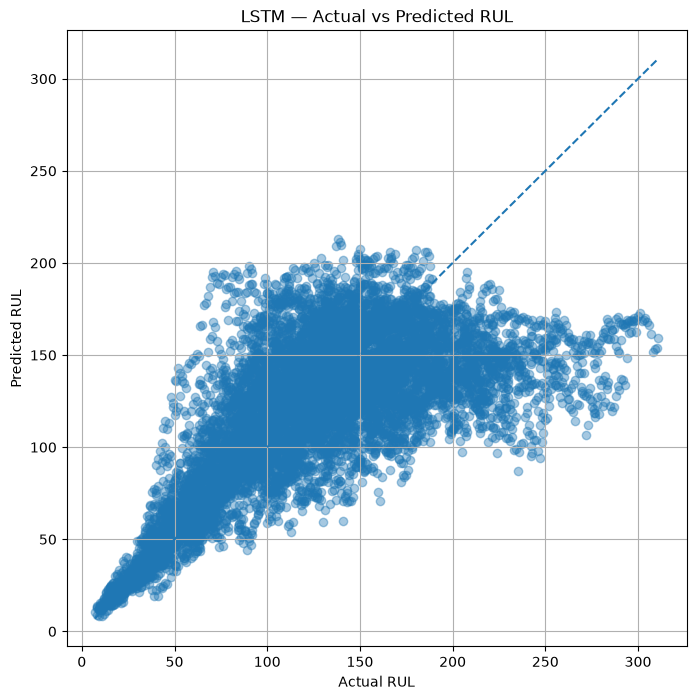

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    results_lstm["Actual_RUL"],
    results_lstm["Predicted_RUL"],
    alpha=0.4
)

# Perfect prediction line
min_rul = min(
    results_lstm["Actual_RUL"].min(),
    results_lstm["Predicted_RUL"].min()
)

max_rul = max(
    results_lstm["Actual_RUL"].max(),
    results_lstm["Predicted_RUL"].max()
)

plt.plot(
    [min_rul, max_rul],
    [min_rul, max_rul],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("LSTM — Actual vs Predicted RUL")
plt.grid(True)

plt.show()

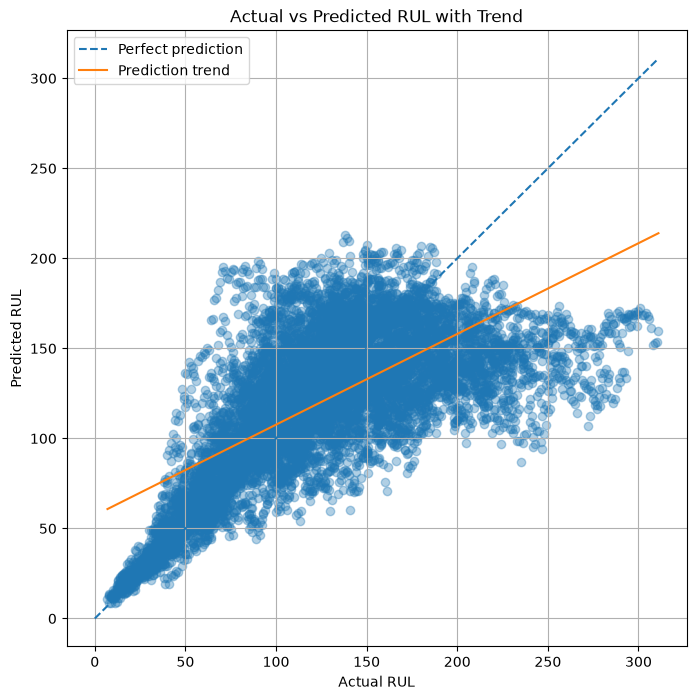

Prediction trend slope: 0.5038739285602724
Prediction trend intercept: 57.26213271097253


In [31]:
plt.figure(figsize=(8, 8))

plt.scatter(
    results_lstm["Actual_RUL"],
    results_lstm["Predicted_RUL"],
    alpha=0.35
)

# Perfect prediction
plt.plot(
    [0, results_lstm["Actual_RUL"].max()],
    [0, results_lstm["Actual_RUL"].max()],
    linestyle="--",
    label="Perfect prediction"
)

# Regression line
z = np.polyfit(
    results_lstm["Actual_RUL"],
    results_lstm["Predicted_RUL"],
    1
)

p = np.poly1d(z)

x_line = np.linspace(
    results_lstm["Actual_RUL"].min(),
    results_lstm["Actual_RUL"].max(),
    100
)

plt.plot(
    x_line,
    p(x_line),
    label="Prediction trend"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL with Trend")
plt.legend()
plt.grid(True)

plt.show()

print("Prediction trend slope:", z[0])
print("Prediction trend intercept:", z[1])

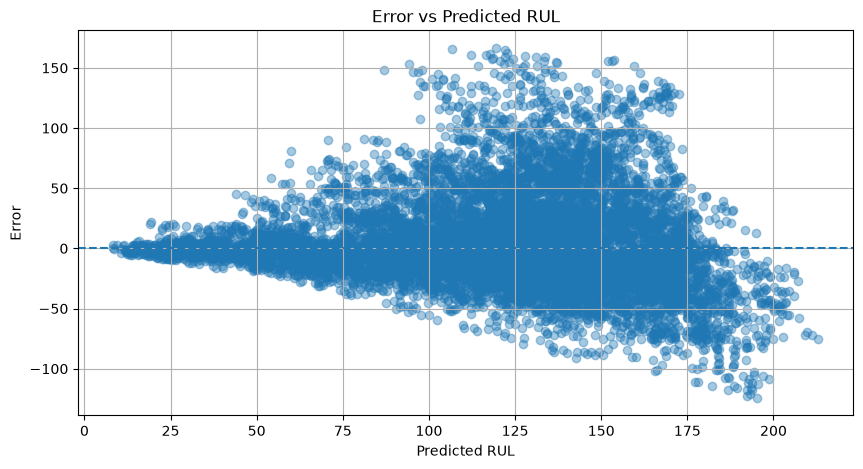

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(
    results_lstm["Predicted_RUL"],
    results_lstm["Error"],
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted RUL")
plt.ylabel("Error")
plt.title("Error vs Predicted RUL")
plt.grid(True)

plt.show()


# Residual = Error here

### Engine-Level Error Analysis

In [26]:
engine_id_test = []
cycle_test = []

WINDOW_SIZE = 30

for engine_id in test_scaled["engine_id"].unique():

    engine_df = (
        test_scaled[test_scaled["engine_id"] == engine_id]
        .sort_values("cycle")
    )

    for i in range(WINDOW_SIZE - 1, len(engine_df)):

        engine_id_test.append(engine_id)

        # Cycle corresponding to the target y
        cycle_test.append(
            engine_df["cycle"].iloc[i]
        )

engine_id_test = np.array(engine_id_test)
cycle_test = np.array(cycle_test)

print("engine_id_test:", engine_id_test.shape)
print("cycle_test:", cycle_test.shape)
print("y_test:", np.asarray(y_test_lstm).shape)
print("y_pred_test:", np.asarray(y_pred_test).shape)

engine_id_test: (10196,)
cycle_test: (10196,)
y_test: (10196,)
y_pred_test: (10196,)


In [28]:
results_test = pd.DataFrame({
    "engine_id": engine_id_test,
    "cycle": cycle_test,
    "Actual_RUL": np.asarray(y_test_lstm).flatten(),
    "Predicted_RUL": np.asarray(y_pred_test).flatten()
})

results_test["Residual"] = (
    results_test["Actual_RUL"] -
    results_test["Predicted_RUL"]
)

results_test["Absolute_Error"] = (
    results_test["Residual"].abs()
)

results_test.head(3)

,engine_id,cycle,Actual_RUL,Predicted_RUL,Residual,Absolute_Error
0,1,30,113,162.687729,-49.687729,49.687729
1,1,31,112,164.945938,-52.945938,52.945938
2,2,30,117,127.805801,-10.805801,10.805801


In [29]:
engine_analysis = (
    results_test
    .groupby("engine_id")
    .agg(
        Samples=("Actual_RUL", "size"),
        MAE=("Absolute_Error", "mean"),
        RMSE=("Residual", lambda x: np.sqrt(np.mean(x**2))),
        Mean_Error=("Residual", "mean"),
        Max_Error=("Absolute_Error", "max")
    )
    .reset_index()
)

In [33]:
engine_analysis = engine_analysis.sort_values(
    "MAE",
    ascending=False
)

engine_analysis.head(10)

,engine_id,Samples,MAE,RMSE,Mean_Error,Max_Error
11,12,188,85.802529,93.149397,85.802529,156.298569
92,93,215,77.321728,88.626335,77.321728,166.540031
88,89,148,74.898566,88.620934,74.898566,158.812767
40,41,94,70.353830,79.465229,-70.351865,124.339951
44,45,123,58.291286,68.583123,57.224010,127.726295
66,67,42,56.283166,66.386021,-53.408209,108.623825
9,10,163,55.063795,61.643709,51.935038,111.959167
47,48,49,54.624018,56.249589,-54.624018,82.369766
12,13,166,54.132324,61.214418,50.430860,103.373672
43,44,25,51.911640,55.273968,-51.911640,77.656525


In [34]:
engine_analysis.sort_values(
    "MAE",
    ascending=True
).head(15)

,engine_id,Samples,MAE,RMSE,Mean_Error,Max_Error
38,39,8,5.247149,5.960688,-1.008192,9.884155
86,87,27,6.212105,7.859218,-3.597072,14.490219
94,95,60,7.057945,8.770010,-6.523520,21.796310
24,25,19,7.961721,9.226292,-2.848410,17.645340
55,56,107,8.580795,11.672019,-6.407564,31.815872
45,46,117,8.762675,11.404441,-0.612289,30.080383
58,59,65,9.625107,12.149500,-4.633013,29.882050
75,76,176,10.157134,12.870084,4.741378,39.024628
23,24,157,11.319925,14.516597,-9.310637,32.128403
65,66,118,11.559520,14.134501,-11.003857,30.107040


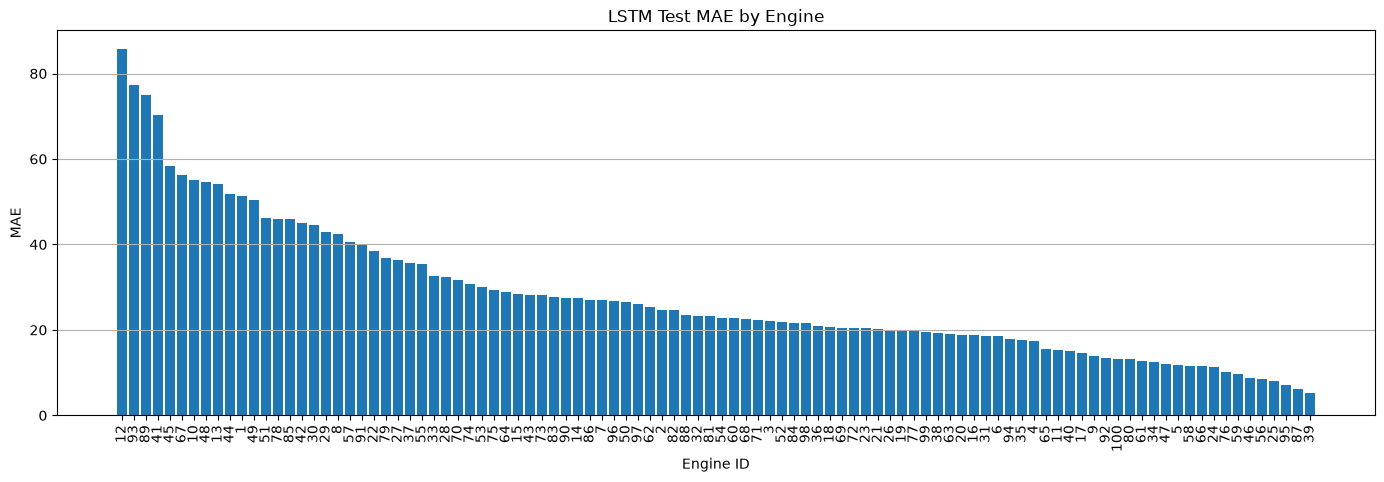

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(17, 5))

plt.bar(
    engine_analysis["engine_id"].astype(str),
    engine_analysis["MAE"]
)

plt.xlabel("Engine ID")
plt.ylabel("MAE")
plt.title("LSTM Test MAE by Engine")
plt.xticks(rotation=90)
plt.grid(axis="y")

plt.show()

In [39]:
worst_engine = engine_analysis.iloc[0]["engine_id"]

print("Worst Engine:", worst_engine)

Worst Engine: 12.0


In [40]:
worst_engine_results = (
    results_test[
        results_test["engine_id"] == worst_engine
    ]
    .sort_values("cycle")
)

worst_engine_results.head()

,engine_id,cycle,Actual_RUL,Predicted_RUL,Residual,Absolute_Error
852,12,30,311,159.499832,151.500168,151.500168
853,12,31,310,153.701431,156.298569,156.298569
854,12,32,309,153.050980,155.949020,155.949020
855,12,33,308,151.861023,156.138977,156.138977
856,12,34,307,161.340622,145.659378,145.659378


In [41]:
print(
    worst_engine_results[
        ["Actual_RUL", "Predicted_RUL", "Residual", "Absolute_Error"]
    ].describe()
)

       Actual_RUL  Predicted_RUL    Residual  Absolute_Error
count  188.000000     188.000000  188.000000      188.000000
mean   217.500000     131.697479   85.802529       85.802529
std     54.415071      24.134998   36.356111       36.356111
min    124.000000      70.493111    3.518303        3.518303
25%    170.750000     119.328331   63.299532       63.299532
50%    217.500000     134.215424   78.461349       78.461349
75%    264.250000     150.989391  119.734787      119.734787
max    311.000000     172.597855  156.298569      156.298569


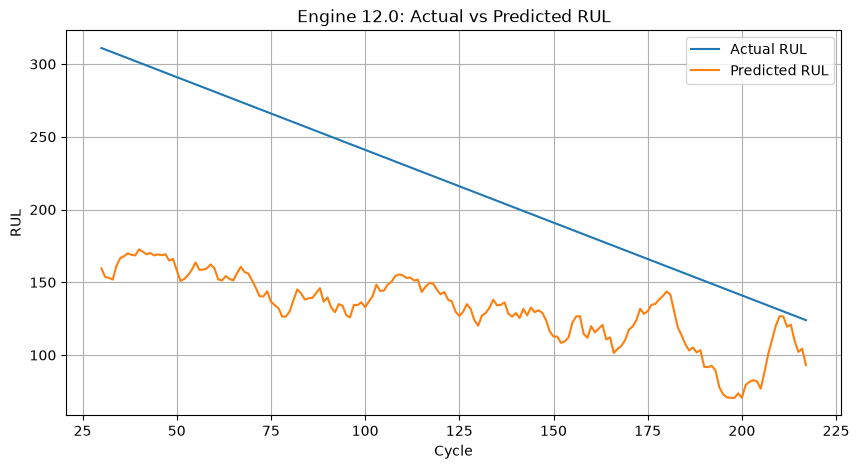

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    worst_engine_results["cycle"],
    worst_engine_results["Actual_RUL"],
    label="Actual RUL"
)

plt.plot(
    worst_engine_results["cycle"],
    worst_engine_results["Predicted_RUL"],
    label="Predicted RUL"
)

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title(f"Engine {worst_engine}: Actual vs Predicted RUL")
plt.legend()
plt.grid(True)

plt.show()

In [50]:
print("Actual RUL range:")
print(results_test["Actual_RUL"].min(),
      results_test["Actual_RUL"].max())

print("\nPredicted RUL range:")
print(results_test["Predicted_RUL"].min(),
      results_test["Predicted_RUL"].max())

print("\nActual RUL mean:",
      results_test["Actual_RUL"].mean())

print("Predicted RUL mean:",
      results_test["Predicted_RUL"].mean())

print("\nActual RUL std:",
      results_test["Actual_RUL"].std())

print("Predicted RUL std:",
      results_test["Predicted_RUL"].std())

Actual RUL range:
7 311

Predicted RUL range:
8.403153419494629 212.89942932128906

Actual RUL mean: 126.94850921930168
Predicted RUL mean: 121.22818

Actual RUL std: 54.58736914134469
Predicted RUL std: 40.50349044799805


In [51]:
bins = [0, 30, 60, 100, 150, 200, 250, 300, 350, np.inf]

labels = [
    "0-30",
    "31-60",
    "61-100",
    "101-150",
    "151-200",
    "201-250",
    "251-300",
    "301-350",
    "350+"
]

results_test["RUL_Range"] = pd.cut(
    results_test["Actual_RUL"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [52]:
range_analysis = (
    results_test
    .groupby("RUL_Range", observed=False)
    .agg(
        Samples=("Actual_RUL", "size"),
        MAE=("Absolute_Error", "mean"),
        RMSE=("Residual", lambda x: np.sqrt(np.mean(x**2))),
        Mean_Error=("Residual", "mean"),
        Mean_Actual=("Actual_RUL", "mean"),
        Mean_Predicted=("Predicted_RUL", "mean")
    )
    .reset_index()
)

range_analysis

,RUL_Range,Samples,MAE,RMSE,Mean_Error,Mean_Actual,Mean_Predicted
0,0-30,332,3.908574,5.092974,-2.911718,21.855422,24.767139
1,31-60,908,13.398897,20.336354,-10.183402,46.634361,56.817764
2,61-100,1954,25.124531,33.970394,-20.343465,82.404811,102.748276
3,101-150,3781,22.538806,28.174130,-7.846081,125.754033,133.600113
4,151-200,2268,30.063687,36.546928,24.157319,170.932540,146.775208
5,201-250,742,76.584148,80.309751,76.584148,219.768194,143.184052
6,251-300,200,123.842224,125.348503,123.842224,270.815000,146.972778
7,301-350,11,142.927984,143.278994,142.927984,306.000000,163.072021
8,350+,0,NaN,NaN,NaN,NaN,NaN


In [53]:
print(
    "Correlation between Actual RUL and Residual:",
    results_test["Actual_RUL"].corr(
        results_test["Residual"]
    )
)

Correlation between Actual RUL and Residual: 0.6733932465611057


In [54]:
print(
    "Correlation between Actual RUL and Absolute Error:",
    results_test["Actual_RUL"].corr(
        results_test["Absolute_Error"]
    )
)

Correlation between Actual RUL and Absolute Error: 0.5864876105200376


In [56]:
engine_stats = (
    results_test
    .groupby("engine_id")
    .agg(
        Samples=("Actual_RUL", "size"),
        MAE=("Absolute_Error", "mean"),
        RMSE=("Residual", lambda x: np.sqrt(np.mean(x**2))),
        Mean_Error=("Residual", "mean"),
        Mean_Actual_RUL=("Actual_RUL", "mean"),
        Max_Actual_RUL=("Actual_RUL", "max"),
        Mean_Predicted_RUL=("Predicted_RUL", "mean")
    )
    .reset_index()
)

In [57]:
engine_stats.sort_values(
    "MAE",
    ascending=False
).head(15)

,engine_id,Samples,MAE,RMSE,Mean_Error,Mean_Actual_RUL,Max_Actual_RUL,Mean_Predicted_RUL
11,12,188,85.802529,93.149397,85.802529,217.5,311,131.697479
92,93,215,77.321728,88.626335,77.321728,192.0,299,114.678268
88,89,148,74.898566,88.620934,74.898566,209.5,283,134.601425
40,41,94,70.353830,79.465229,-70.351865,64.5,111,134.851868
44,45,123,58.291286,68.583123,57.224010,175.0,236,117.775986
66,67,42,56.283166,66.386021,-53.408209,97.5,118,150.908203
9,10,163,55.063795,61.643709,51.935038,177.0,258,125.064972
47,48,49,54.624018,56.249589,-54.624018,116.0,140,170.624023
12,13,166,54.132324,61.214418,50.430860,177.5,260,127.069138
43,44,25,51.911640,55.273968,-51.911640,121.0,133,172.911636


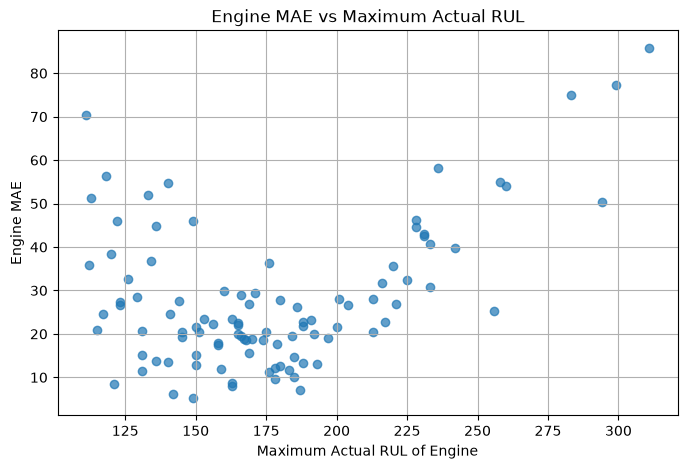

In [58]:
plt.figure(figsize=(8, 5))

plt.scatter(
    engine_stats["Max_Actual_RUL"],
    engine_stats["MAE"],
    alpha=0.7
)

plt.xlabel("Maximum Actual RUL of Engine")
plt.ylabel("Engine MAE")
plt.title("Engine MAE vs Maximum Actual RUL")
plt.grid(True)

plt.show()

In [59]:
print(
    "Correlation:",
    engine_stats["Max_Actual_RUL"].corr(
        engine_stats["MAE"]
    )
)

Correlation: 0.4046299533471064


In [60]:
print(
    "Correlation with mean RUL:",
    engine_stats["Mean_Actual_RUL"].corr(
        engine_stats["MAE"]
    )
)

Correlation with mean RUL: 0.39187866125418686


In [25]:
import joblib

xgb_model = joblib.load("xgboost_rul.pkl")

In [39]:
xgb_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [40]:
feature_cols = [
    col for col in test_scaled.columns
    if col not in ['engine_id', 'RUL']
]

In [41]:
X_test_xgb = test_scaled[feature_cols].copy()

In [42]:
y_test_xgb = test_scaled["RUL"].copy()

In [43]:
feature_cols

['cycle',
 'op_setting_1',
 'op_setting_2',
 'op_setting_3',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21']

In [44]:
y_pred_test_xgb = xgb_model.predict(X_test_xgb)

In [45]:
print("Actual:", y_test_xgb.shape)
print("Predicted:", y_pred_test_xgb.shape)

Actual: (13096,)
Predicted: (13096,)


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_test_mae = mean_absolute_error(
    y_test_xgb,
    y_pred_test_xgb
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test_xgb,
        y_pred_test_xgb
    )
)

xgb_test_r2 = r2_score(
    y_test_xgb,
    y_pred_test_xgb
)

print("Final XGBoost Test Results")
print("--------------------------")
print("MAE :", xgb_test_mae)
print("RMSE:", xgb_test_rmse)
print("R²  :", xgb_test_r2)

Final XGBoost Test Results
--------------------------
MAE : 39.79603958129883
RMSE: 53.3014876338773
R²  : 0.18322843313217163
